In [1]:
# Gerekli kütüphaneleri yükleyelim
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from qiskit.quantum_info import Statevector
import math
import matplotlib.pyplot as plt

In [2]:
simulator = AerSimulator()

In [ ]:
def run_on_simulators(circuit):
    # Devrede henüz ölçüm yokken teorik kuantum durumunu alınır
    statevec = Statevector.from_instruction(circuit)
    
    meas_circuit = circuit.copy()
    num_qubits = circuit.num_qubits
    
    # Eğer klasik bit tanımlanmamışsa ölçüm için ekleynir
    if meas_circuit.num_clbits == 0:
        meas_circuit.measure_all()
    else:
        meas_circuit.measure(range(num_qubits), range(num_qubits))
    
    # Devreyi simülatörün diline çevir (transpile)
    t_circ = transpile(meas_circuit, simulator)
    
    result = simulator.run(t_circ, shots=1024).result()
    counts = result.get_counts()
    
    return statevec, counts


Boş Devre


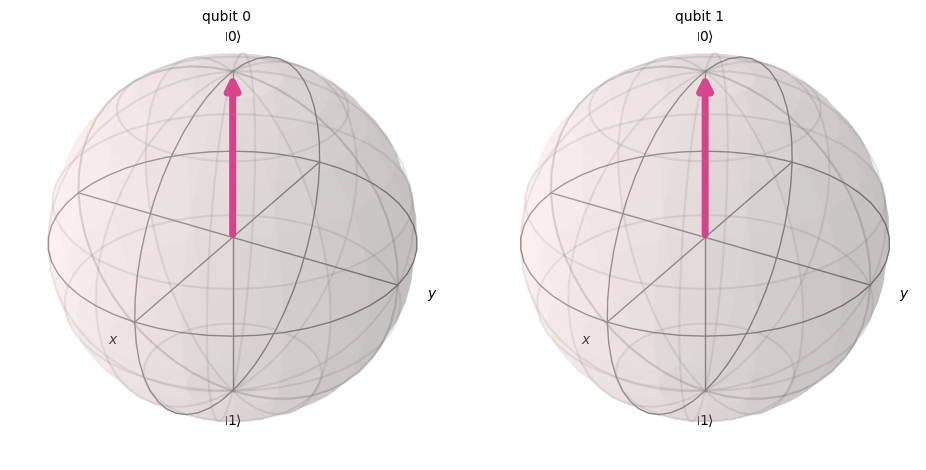

In [5]:
# BOŞ DEVRE (00 Durumu)
print("Boş Devre")
circuit = QuantumCircuit(2, 2)
statevec, counts = run_on_simulators(circuit)
display(plot_bloch_multivector(statevec))

--- Hadamard ---


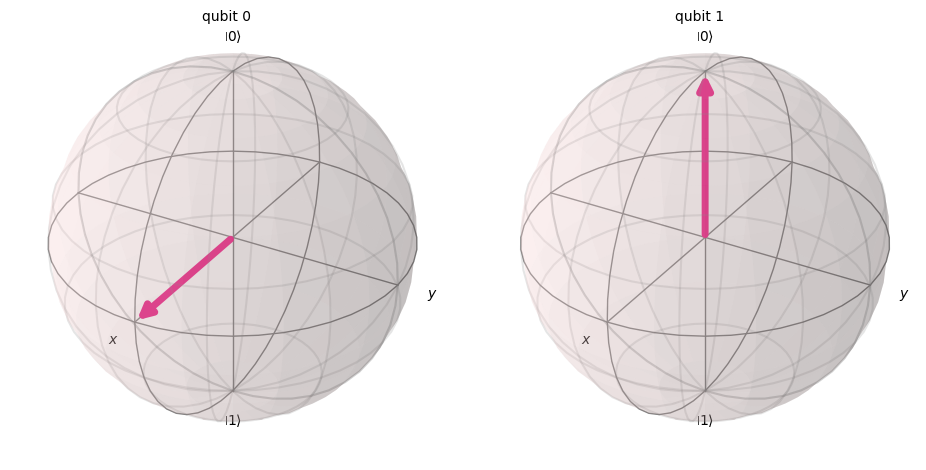

In [ ]:
# HADAMARD (Süperpozisyon)
print("--- Hadamard ---")
circuit.h(0)
statevec, counts = run_on_simulators(circuit)
display(plot_bloch_multivector(statevec))

Bell Durumu (Entanglement)


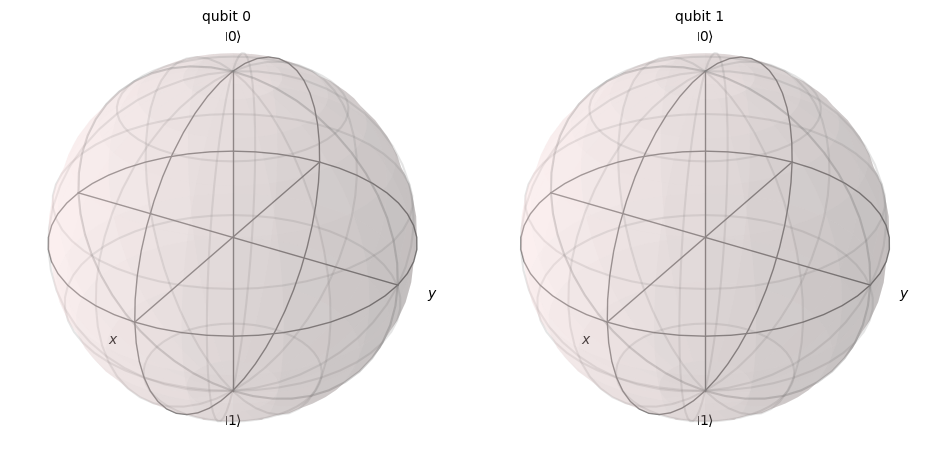

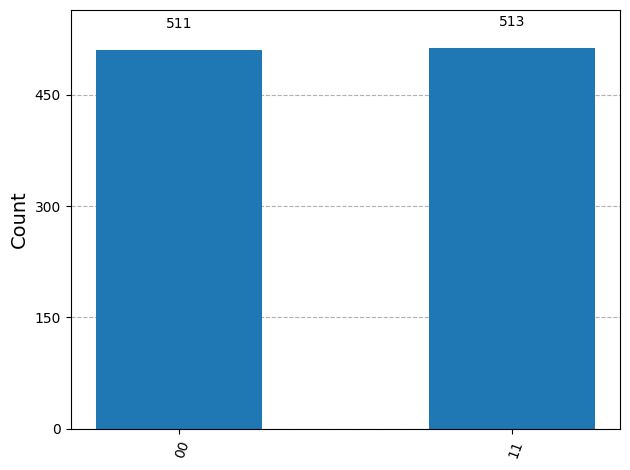

In [6]:
# BELL DURUMU (Dolaşıklık)
print("Bell Durumu (Entanglement)")
circuit = QuantumCircuit(2, 2)
circuit.h(0)
circuit.cx(0, 1)
statevec, counts = run_on_simulators(circuit)
display(plot_bloch_multivector(statevec))
display(plot_histogram(counts))

Rx Kapıları


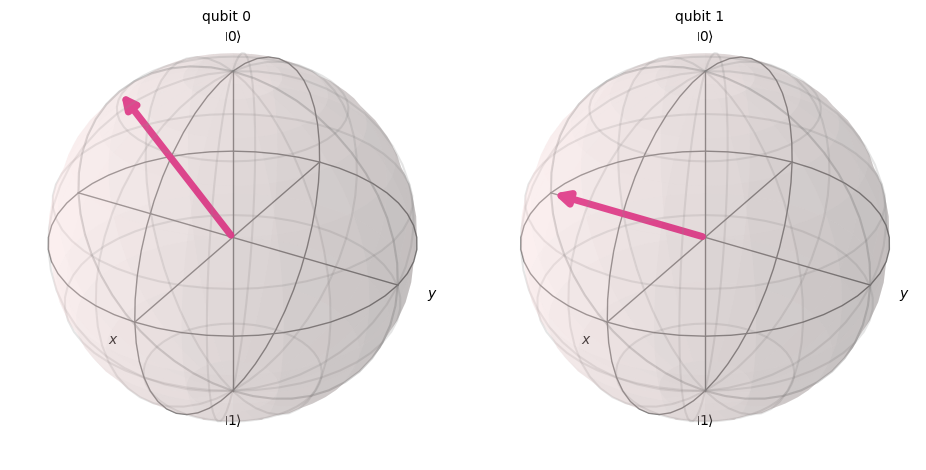

In [7]:
# Rx KAPILARI (X Ekseninde Dönüş)
print("Rx Kapıları")
circuit = QuantumCircuit(2, 2)
circuit.rx(math.pi/4, 0)
circuit.rx(math.pi/2, 1)
statevec, counts = run_on_simulators(circuit)
display(plot_bloch_multivector(statevec))

--- Ry Kapıları ---


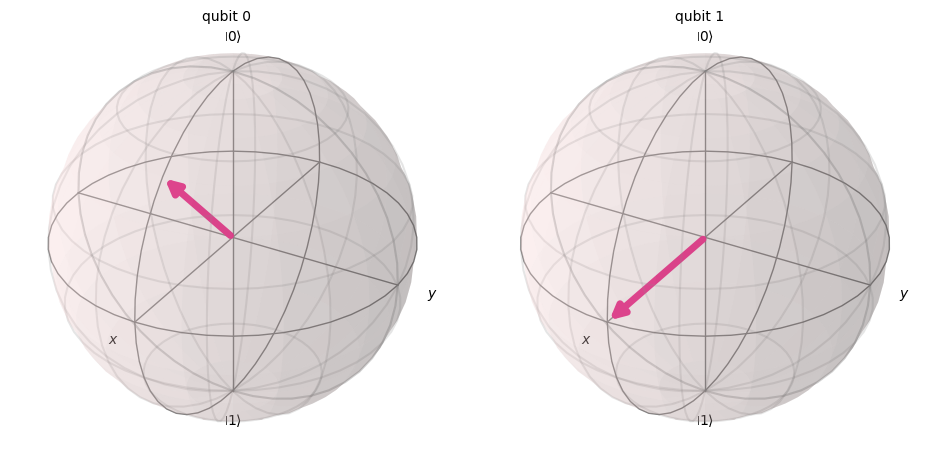

In [ ]:
# Ry KAPILARI (Y Ekseninde Dönüş)
print("Ry Kapıları")
circuit = QuantumCircuit(2, 2)
circuit.ry(math.pi/4, 0)
circuit.ry(math.pi/2, 1)
statevec, counts = run_on_simulators(circuit)
display(plot_bloch_multivector(statevec))

Tek Kübit H


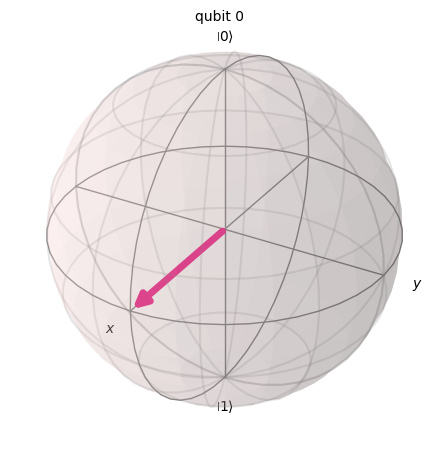

In [9]:

# TEK KÜBİT HADAMARD
print("Tek Kübit H")
circuit = QuantumCircuit(1, 1)
circuit.h(0)
statevec, counts = run_on_simulators(circuit)
display(plot_bloch_multivector(statevec))

H + Z Kapısı


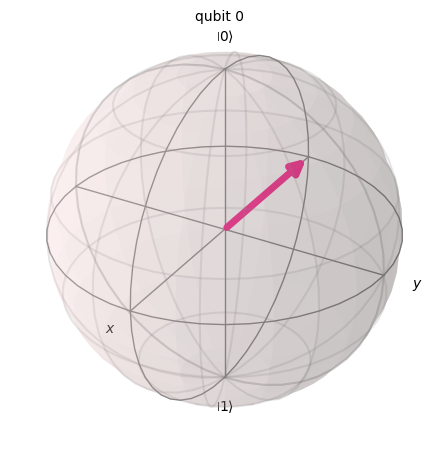

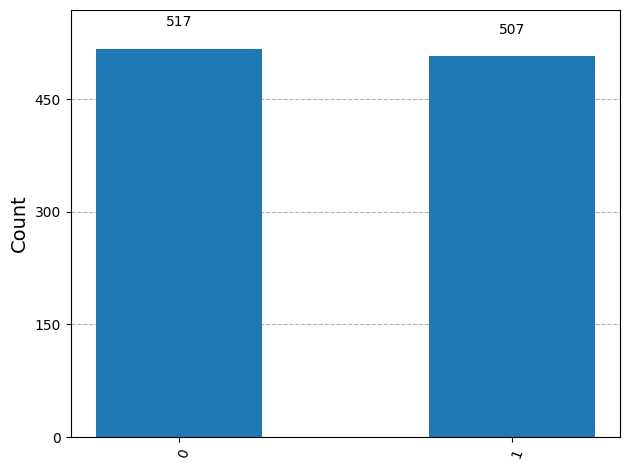

In [10]:
# HADAMARD + Z KAPISI
print("H + Z Kapısı")
circuit = QuantumCircuit(1, 1)
circuit.h(0)
circuit.z(0)
statevec, counts = run_on_simulators(circuit)
display(plot_bloch_multivector(statevec))
display(plot_histogram(counts))